In [2]:
# Importing the library needed for the code
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import scipy.stats as stats
import yfinance as yf

In [12]:
# Downloading the HSI data needed from yfinance
hsi = yf.Ticker("^HSI")
data = hsi.history(start="2022-01-01",end=pd.Timestamp.today().strftime("%Y-%m-%d"))
close = data['Close'].dropna()

close.tail()

Date
2026-08-06 00:00:00+08:00    25530.279297
2026-08-07 00:00:00+08:00    25668.029297
2026-08-10 00:00:00+08:00    25937.490234
2026-08-11 00:00:00+08:00    25652.820312
2026-08-12 00:00:00+08:00    25440.169922
Name: Close, dtype: float64

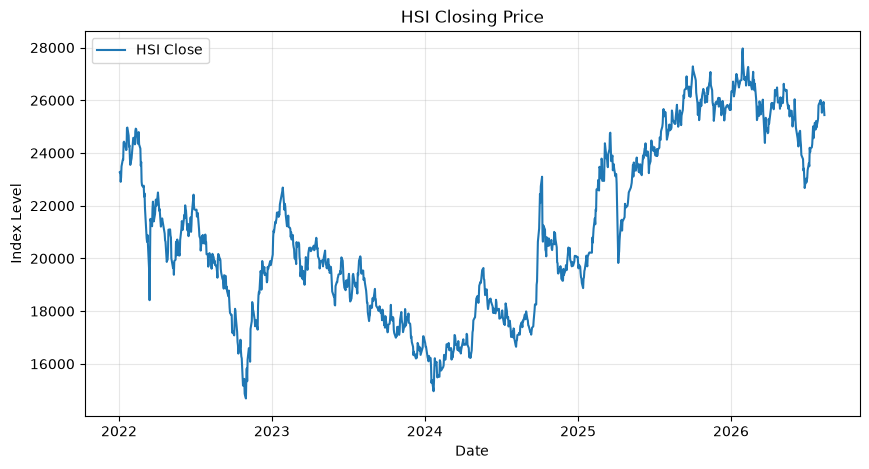

In [13]:
# Plot the graph for the past 5 year hsi closing price change
plt.figure(figsize=(10,5))
plt.plot(close.index, close, label='HSI Close')
plt.title("HSI Closing Price")
plt.xlabel('Date')
plt.ylabel('Index Level')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
# Calculate the log_return of HSI based on the data
log_returns = np.log(close/close.shift(1)).dropna()

# Remember about the shape of close is (1130,1), which close function will calculate log returns by shifting 1 right then use current close
# divided by yesterday close then apply this calculation to every cell inside the tuple along x-axis

log_returns.shape

(1129,)

In [ ]:
# Summary Statistics
mean_return = log_returns.mean()
std_daily = log_returns.std()
annualized_volatility = std_daily * np.sqrt(252)
skewness = log_returns.skew()
kurtosis = log_returns.kurtosis()

print(f"Mean daily log return: {float(mean_return):.6f}")
print(f"Daily volatility (std): {std_daily:.6f}")
print(f"Annualized volatility: {annualized_volatility:.4f}")
print(f"Skewness: {skewness:.4f}")
print(f"Excess Kurtosis: {kurtosis:.4f}")

# Remmeber that f string could only allow normal datatypes but not like series or dataframe, check the shape of your variable before using it

Mean daily log return: 0.000079
Daily volatility (std): 0.016202
Annualized volatility: 0.2572
Skewness: -0.3331
Excess Kurtosis: 7.7207


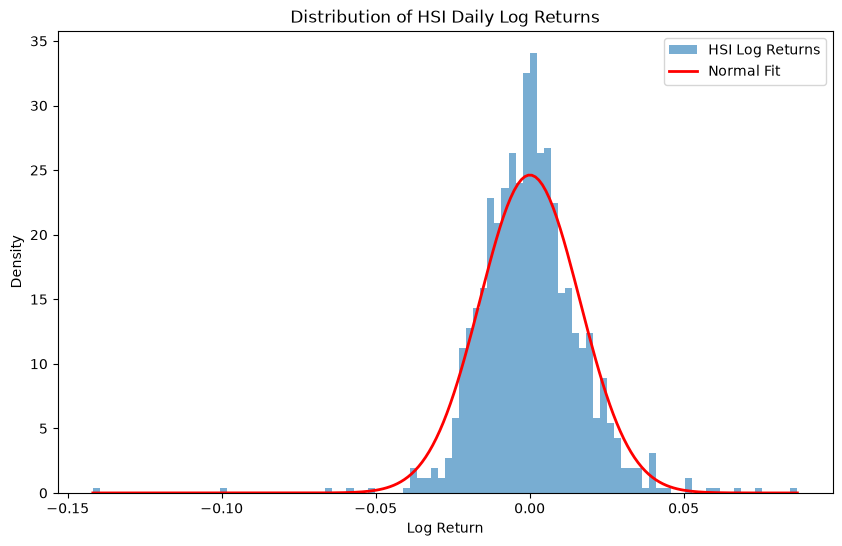

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(log_returns, bins=100, density=True, alpha=0.6, label='HSI Log Returns')

# Overlay fitted normal distribution
mu = mean_return
sigma = std_daily
x = np.linspace(log_returns.min(), log_returns.max(), 200)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Fit')

plt.title('Distribution of HSI Daily Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Density')
plt.legend()
plt.show()

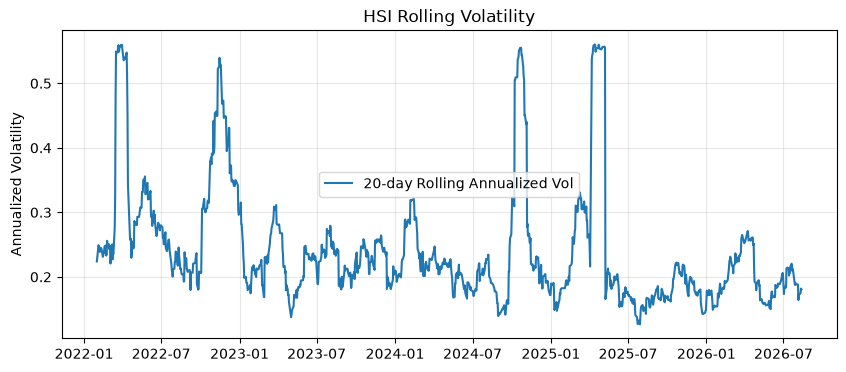

In [ ]:
# Volatility clusters: periods of high volatility are followed by high volatility.
rolling_vol = log_returns.rolling(window=20).std() * np.sqrt(252)

plt.figure(figsize=(10, 4))
plt.plot(rolling_vol.index, rolling_vol, label='20-day Rolling Annualized Vol')
plt.title('HSI Rolling Volatility')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Notice the spikes during market crises. 
# This indicates that volatility is not constant, another violation of the simple Black-Scholes assumption.

## Market Observations – Week 1

- HSI log returns exhibit negative skewness, meaning large down moves are more likely than large up moves.
- The excess kurtosis is positive, indicating fat tails relative to a normal distribution.
- Rolling volatility shows clustering: periods of calm are interrupted by sharp spikes.
- These features imply that the assumptions behind basic Brownian motion are violated in real markets. This motivates the need for stochastic volatility models (e.g., Heston) and volatility skew modeling.